# EDA (Electrodermal Activity)

- Known as **galvanic skin responses or skin conductance**
- EDA measures the electrical conductance of the skin, which varies with moisture level. It's particularly useful for stress and affect detection because:
    1. Emotional arousal and stress trigger sweat gland activity
    2. Increased perspiration increases skin conductance
    3. It's a physiological indicator of sympathetic nervous system activation

## References
1. claude-4.5-sonnet

In [1]:
import os
import sys

import pandas as pd

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../signal'))

from data_processing import DataProcessing

## Load Data

In [2]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
data_path = os.path.join(base_data_path, 'WESAD/all_subjects/chest.csv')
df = DataProcessing.load_from_file(data_path, file_type='csv')
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130950,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
60807595,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
60807596,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859740,0.233459,S17,0
60807597,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864290,0.318909,S17,0
60807598,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


In [3]:
copy_df = df.copy()
copy_df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130950,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
60807595,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
60807596,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859740,0.233459,S17,0
60807597,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864290,0.318909,S17,0
60807598,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


## Keep Meaningful Labels

- 0 = not defined / transient
- 1 = baseline
- 2 = stress
- 3 = amusement
- 4 = meditation
- 5/6/7 = should be ignored in this dataset

In [4]:
filt_labels = copy_df['label'].isin([0, 5, 6, 7])
copy_df = copy_df[~filt_labels]
copy_df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
214583,0.8914,-0.1102,-0.2576,0.030945,-0.003708,5.710983,29.083618,1.191711,S2,1
214584,0.8926,-0.1086,-0.2544,0.033646,-0.014145,5.719376,29.122437,1.139832,S2,1
214585,0.8930,-0.1094,-0.2580,0.033005,0.010208,5.706406,29.115234,1.141357,S2,1
214586,0.8934,-0.1082,-0.2538,0.031815,0.012634,5.712509,29.126709,1.155090,S2,1
214587,0.8930,-0.1096,-0.2570,0.030350,0.002060,5.727005,29.100860,1.133728,S2,1
...,...,...,...,...,...,...,...,...,...,...
60620859,0.4826,-0.0094,-0.8248,0.195236,0.013962,7.021713,34.080353,14.350891,S17,4
60620860,0.4838,-0.0088,-0.8298,0.178574,0.013504,7.020569,34.084900,14.419556,S17,4
60620861,0.4872,-0.0086,-0.8294,0.158020,0.024353,7.020569,34.022460,14.363098,S17,4
60620862,0.4858,-0.0080,-0.8376,0.129959,0.004623,7.029724,34.063538,14.361572,S17,4


## Signal of Interest

In [5]:
signal_name = 'EDA'
signal_df = copy_df.loc[:, [signal_name, 'subject', 'label']]
signal_df

,EDA,subject,label
214583,5.710983,S2,1
214584,5.719376,S2,1
214585,5.706406,S2,1
214586,5.712509,S2,1
214587,5.727005,S2,1
...,...,...,...
60620859,7.021713,S17,4
60620860,7.020569,S17,4
60620861,7.020569,S17,4
60620862,7.029724,S17,4


## Clean Data

In [6]:
import neurokit2 as nk
def get_cleaned_eda(df, col_name, hz: int = 700):
    df = df.copy()
    cleaned_series = nk.eda_clean(df[col_name], hz)
    df[f'Cleaned {col_name}'] = cleaned_series

    return df

In [7]:
# cleaned_signal_df = DataProcessing.get_cleaned_data(signal_df, signal_name, 700)
cleaned_signal_df = get_cleaned_eda(signal_df, signal_name, 700)
cleaned_signal_df

,EDA,subject,label,Cleaned EDA
214583,5.710983,S2,1,5.713918
214584,5.719376,S2,1,5.713804
214585,5.706406,S2,1,5.713689
214586,5.712509,S2,1,5.713573
214587,5.727005,S2,1,5.713455
...,...,...,...,...
60620859,7.021713,S17,4,7.025344
60620860,7.020569,S17,4,7.025344
60620861,7.020569,S17,4,7.025344
60620862,7.029724,S17,4,7.025344


## Set each subject with new row 0

In [8]:
new_signal_df = DataProcessing.reset_rows(cleaned_signal_df)
new_signal_df

,EDA,subject,label,Cleaned EDA
0,5.710983,S2,1,5.713918
1,5.719376,S2,1,5.713804
2,5.706406,S2,1,5.713689
3,5.712509,S2,1,5.713573
4,5.727005,S2,1,5.713455
...,...,...,...,...
2104895,7.021713,S17,4,7.025344
2104896,7.020569,S17,4,7.025344
2104897,7.020569,S17,4,7.025344
2104898,7.029724,S17,4,7.025344


In [9]:
subjects = new_signal_df['subject'].unique()
subjects

array(['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11',
       'S13', 'S14', 'S15', 'S16', 'S17'], dtype=object)

In [10]:
def check_order(s_df):
    # s is a Series here
    s = s_df.loc[s_df['label'].isin([3, 4]), 'label']

    run_starts = s[s.ne(s.shift())]
    run_order = run_starts.to_numpy()

    # print(type(run_order))
    return run_order

In [11]:
for subject in subjects:
    print(subject)

    s_df = DataProcessing.get_specific_subject_df(new_signal_df, subject)
    order = check_order(s_df)
    print(order)
    import numpy as np
    normal = np.array_equal(order, [3, 4])
    abnormal = np.array_equal(order, [4, 3, 4])

    print(f"Normal: {normal}")
    print(f"Abnormal: {abnormal}")

S2
[4 3 4]
Normal: False
Abnormal: True
S3
[4 3 4]
Normal: False
Abnormal: True
S4
[3 4]
Normal: True
Abnormal: False
S5
[3 4]
Normal: True
Abnormal: False
S6
[4 3 4]
Normal: False
Abnormal: True
S7
[3 4]
Normal: True
Abnormal: False
S8
[3 4]
Normal: True
Abnormal: False
S9
[4 3 4]
Normal: False
Abnormal: True
S10
[3 4]
Normal: True
Abnormal: False
S11
[4 3 4]
Normal: False
Abnormal: True
S13
[3 4]
Normal: True
Abnormal: False
S14
[4 3 4]
Normal: False
Abnormal: True
S15
[3 4]
Normal: True
Abnormal: False
S16
[4 3 4]
Normal: False
Abnormal: True
S17
[3 4]
Normal: True
Abnormal: False


### Ex to get specific subject

In [12]:
s_df = DataProcessing.get_specific_subject_df(new_signal_df, 'S4')
s_df

,EDA,subject,label,Cleaned EDA
0,1.343536,S4,1,4.188673
1,1.316452,S4,1,4.137287
2,1.325989,S4,1,4.085922
3,1.280975,S4,1,4.034594
4,1.357651,S4,1,3.983319
...,...,...,...,...
2078996,2.528763,S4,4,4.310937
2078997,2.527237,S4,4,4.344715
2078998,2.539825,S4,4,4.378528
2078999,2.535248,S4,4,4.412368


In [13]:
labels = new_signal_df['label'].unique()
labels

array([1, 2, 4, 3])

In [14]:
s_df.drop(columns=['subject'], inplace=True)

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_26866/2951368449.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_df.drop(columns=['subject'], inplace=True)


In [15]:
def filt_label_data(label):
    filt_label_df = (s_df['label'] == label)
    return s_df[filt_label_df]

In [16]:
label_dfs = []
for label in labels:
    label_df = filt_label_data(label)
    label_dfs.append(label_df)

In [22]:
baseline_df = label_dfs[0]
baseline_df

,EDA,Cleaned EDA
0,1.343536,4.188673
1,1.316452,4.137287
2,1.325989,4.085922
3,1.280975,4.034594
4,1.357651,3.983319
...,...,...
810596,1.306152,1.331067
810597,1.304245,1.331420
810598,1.298141,1.331773
810599,1.300430,1.332127


In [ ]:
# baseline_df.drop(columns=['label'], inplace=True)

<Axes: >

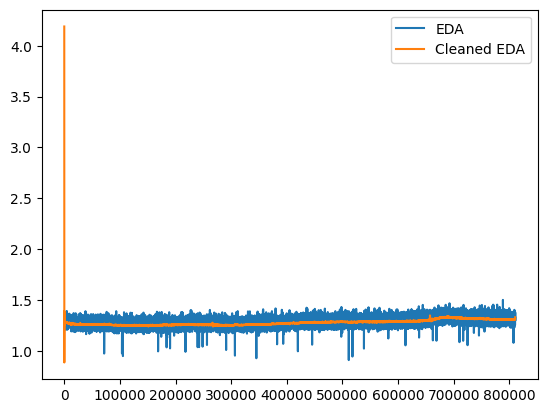

In [ ]:
# baseline_df.plot()

In [24]:
baseline_time_df = DataProcessing.create_time_df(baseline_df, 700)
baseline_time_df

,EDA,Cleaned EDA,Milliseconds,Seconds,Time
0,1.343536,4.188673,0.00,0.00000,0 days 00:00:00
1,1.316452,4.137287,1.43,0.00143,0 days 00:00:00
2,1.325989,4.085922,2.86,0.00286,0 days 00:00:00
3,1.280975,4.034594,4.29,0.00429,0 days 00:00:00
4,1.357651,3.983319,5.71,0.00571,0 days 00:00:00.010000
...,...,...,...,...,...
810596,1.306152,1.331067,1157994.29,1157.99429,0 days 00:19:17.990000
810597,1.304245,1.331420,1157995.71,1157.99571,0 days 00:19:18
810598,1.298141,1.331773,1157997.14,1157.99714,0 days 00:19:18
810599,1.300430,1.332127,1157998.57,1157.99857,0 days 00:19:18


In [26]:
segment_baseline_df, per_window_df = DataProcessing.get_segments_by_duration(baseline_time_df, 60)
segment_baseline_df

,EDA,Cleaned EDA,Milliseconds,Seconds,Time,window_id,window_start_seconds,window_end_seconds
0,1.343536,4.188673,0.00,0.00000,0 days 00:00:00,0,0,60
1,1.316452,4.137287,1.43,0.00143,0 days 00:00:00,0,0,60
2,1.325989,4.085922,2.86,0.00286,0 days 00:00:00,0,0,60
3,1.280975,4.034594,4.29,0.00429,0 days 00:00:00,0,0,60
4,1.357651,3.983319,5.71,0.00571,0 days 00:00:00.010000,0,0,60
...,...,...,...,...,...,...,...,...
810596,1.306152,1.331067,1157994.29,1157.99429,0 days 00:19:17.990000,19,1140,1200
810597,1.304245,1.331420,1157995.71,1157.99571,0 days 00:19:18,19,1140,1200
810598,1.298141,1.331773,1157997.14,1157.99714,0 days 00:19:18,19,1140,1200
810599,1.300430,1.332127,1157998.57,1157.99857,0 days 00:19:18,19,1140,1200


In [41]:
window_ids = segment_baseline_df['window_id'].unique()
window_ids

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

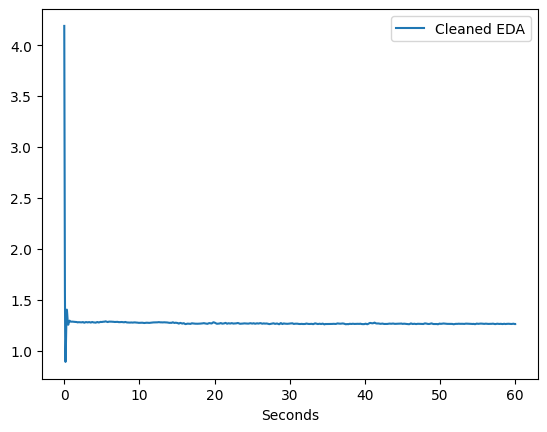

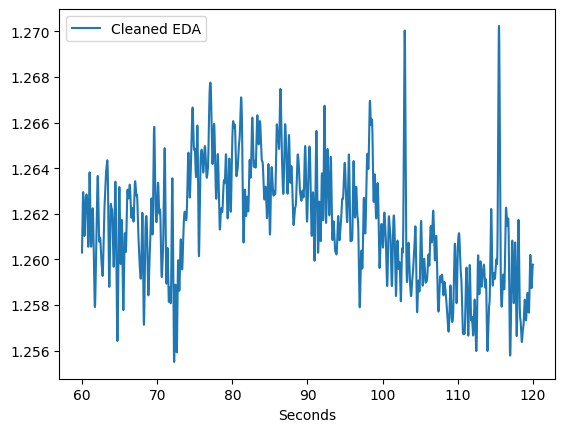

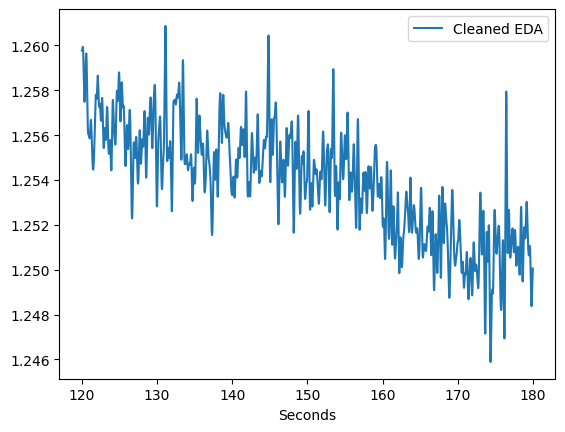

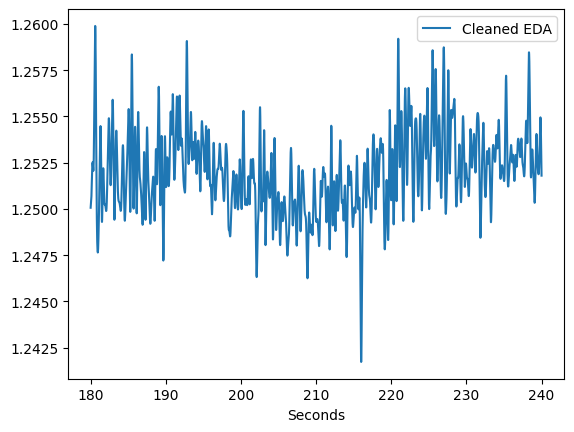

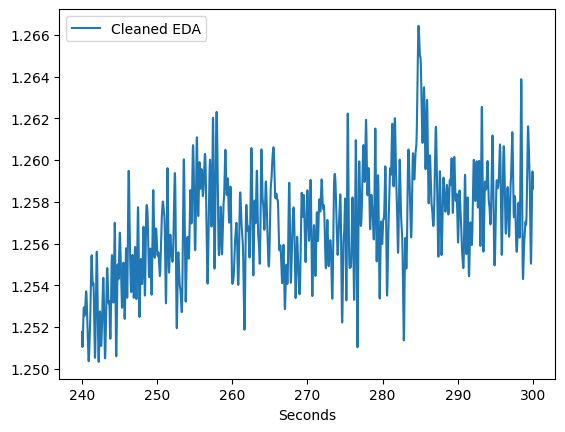

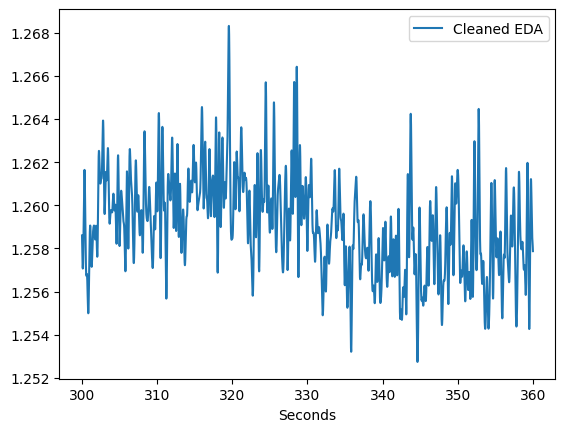

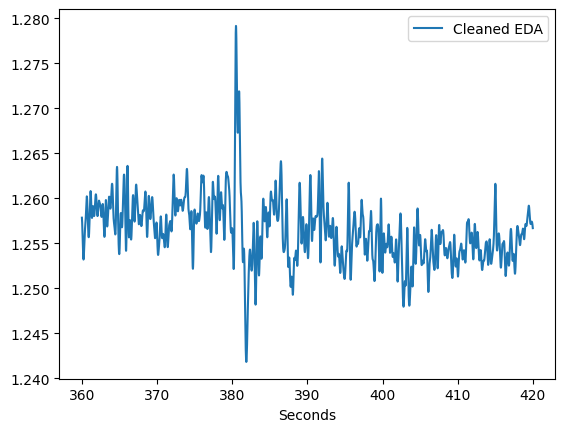

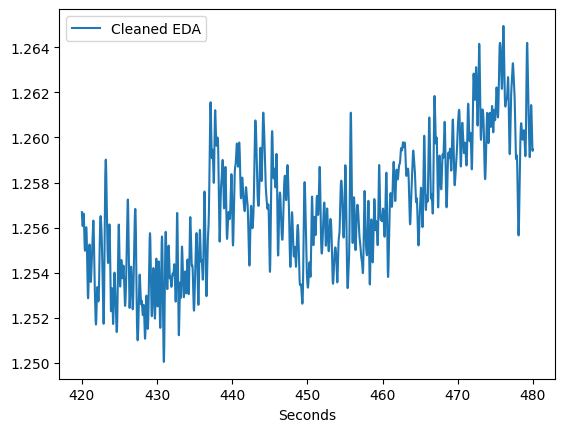

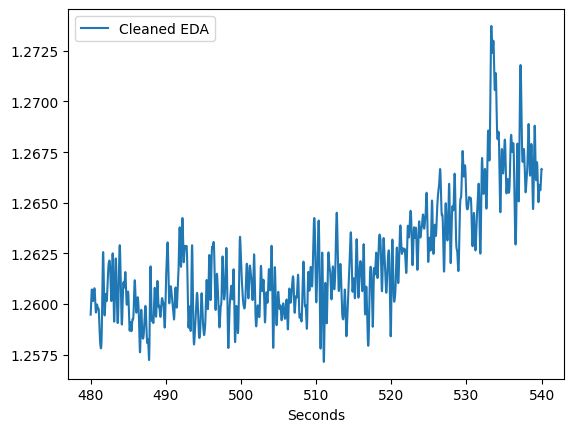

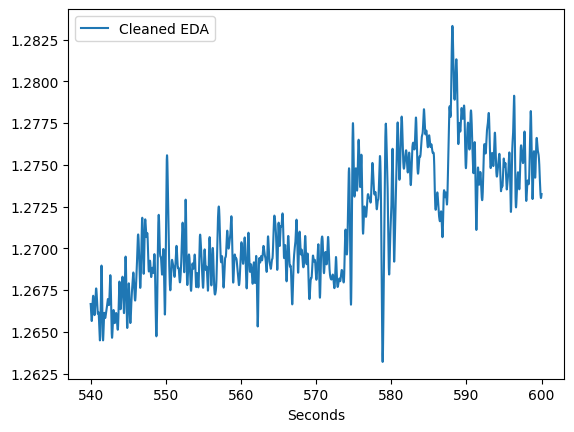

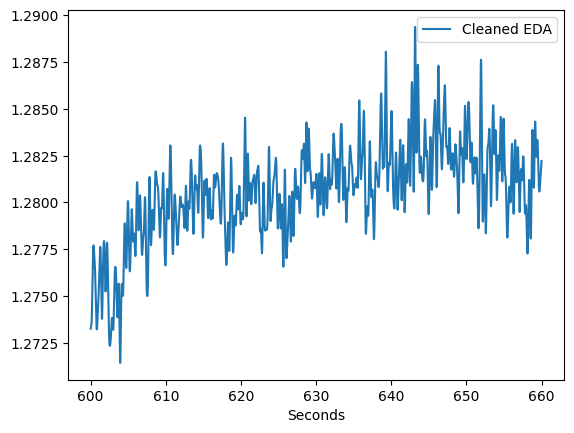

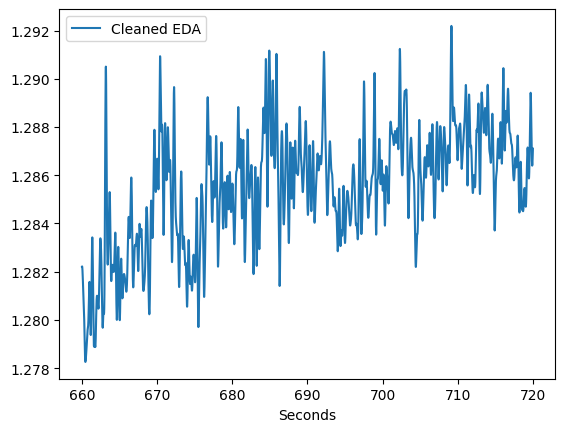

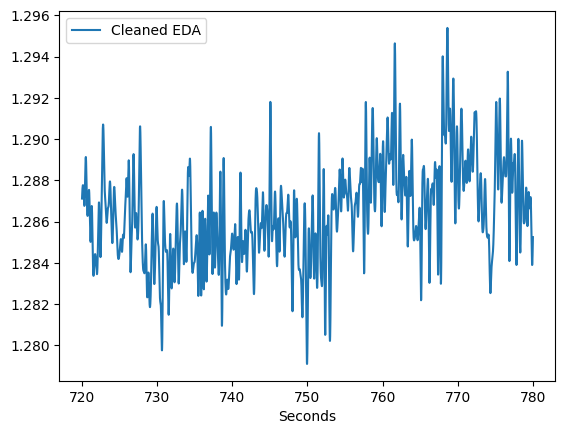

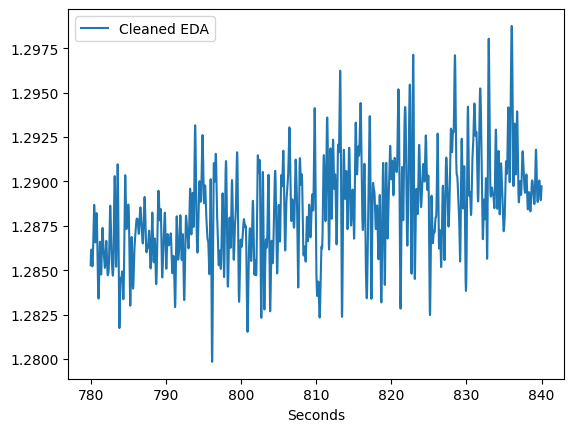

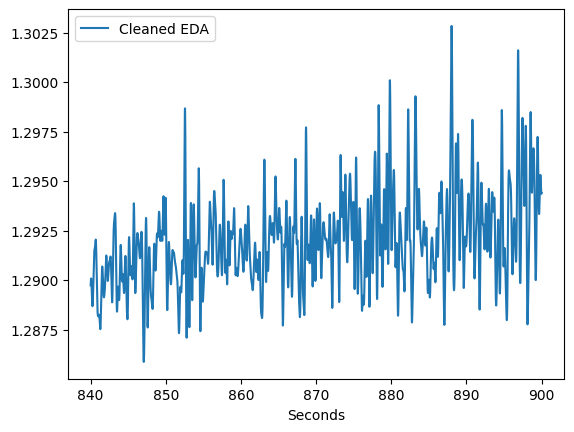

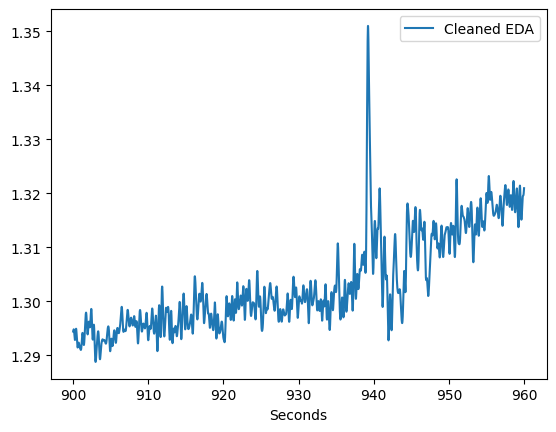

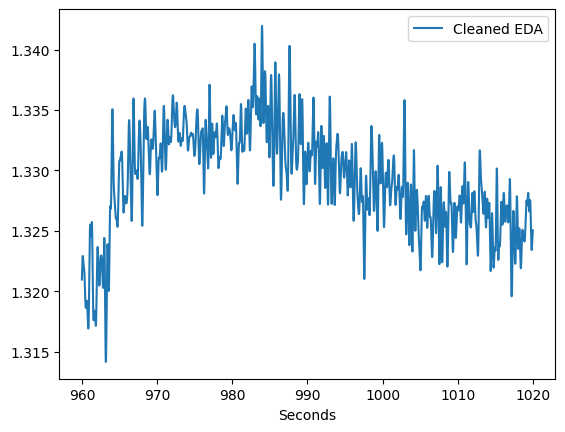

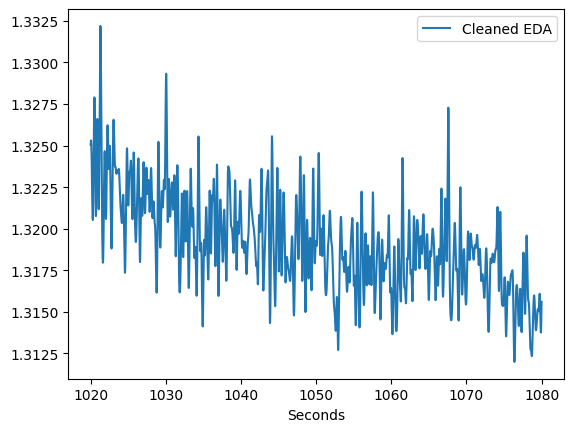

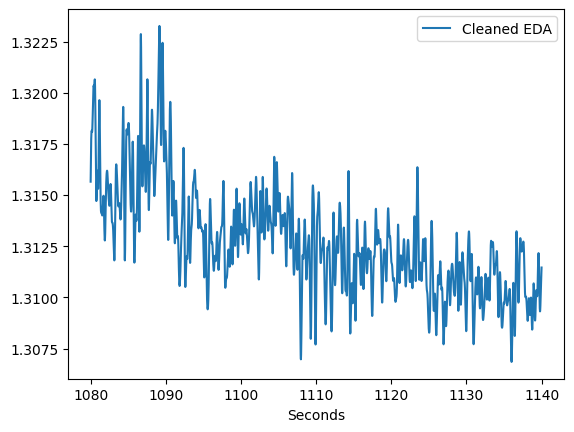

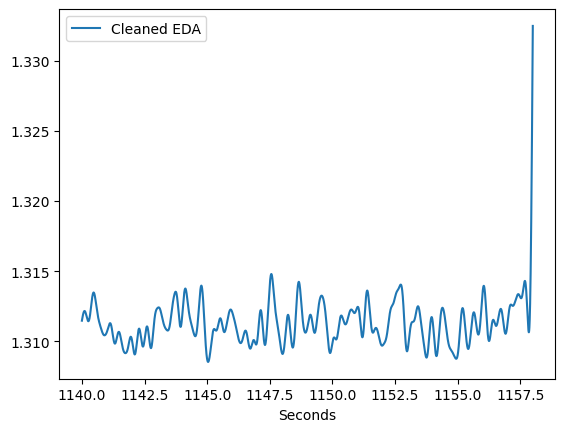

In [ ]:
for window_id in window_ids:
    filt_window = (segment_baseline_df['window_id'] == window_id)
    window_df = segment_baseline_df[filt_window]
    window_df.plot(x='Seconds', y='Cleaned EDA')